### Feature Scaling: Normalization & Standardization
One of the core concepts in machine learning world is the role of normalization and standardization techniques in preprocessing the data. In this notebook we will try to explain what each exactly means and show some common scenarios in which they play crucial role to get an accurate result.

Let's start with defining what a normalization and standardization do with our data. Both of them are an example of feature scaling and goal of the both is to introduce a common scale among the data.

x - raw feature data

$\frac{x-7}{2}$ - data shifted to the left by 7 and scaled down by a factor of 2'

$\frac{x - x_{min}}{x_{max} - x_{min}}$ - min/max normalization. This maps the data to a range of 0 to 1, where 0 is the smallest value of the feature and 1 is the largest.

$\frac{x - x_{mean}}{\sigma}$ - standardization, it makes sure the mean of our values is 0 and the standard deviation of the feature is 1. Additionally let's mention the formula for standard deviation: $\sigma = \sqrt{\frac{\sum (x - x_{mean})^2}{N}}$, where N is a total number of the data points.


Let's jump into some visualizations. We will use histograms for the values (as the X-axis) to showcase the frequency of each value that our scaled data shows.

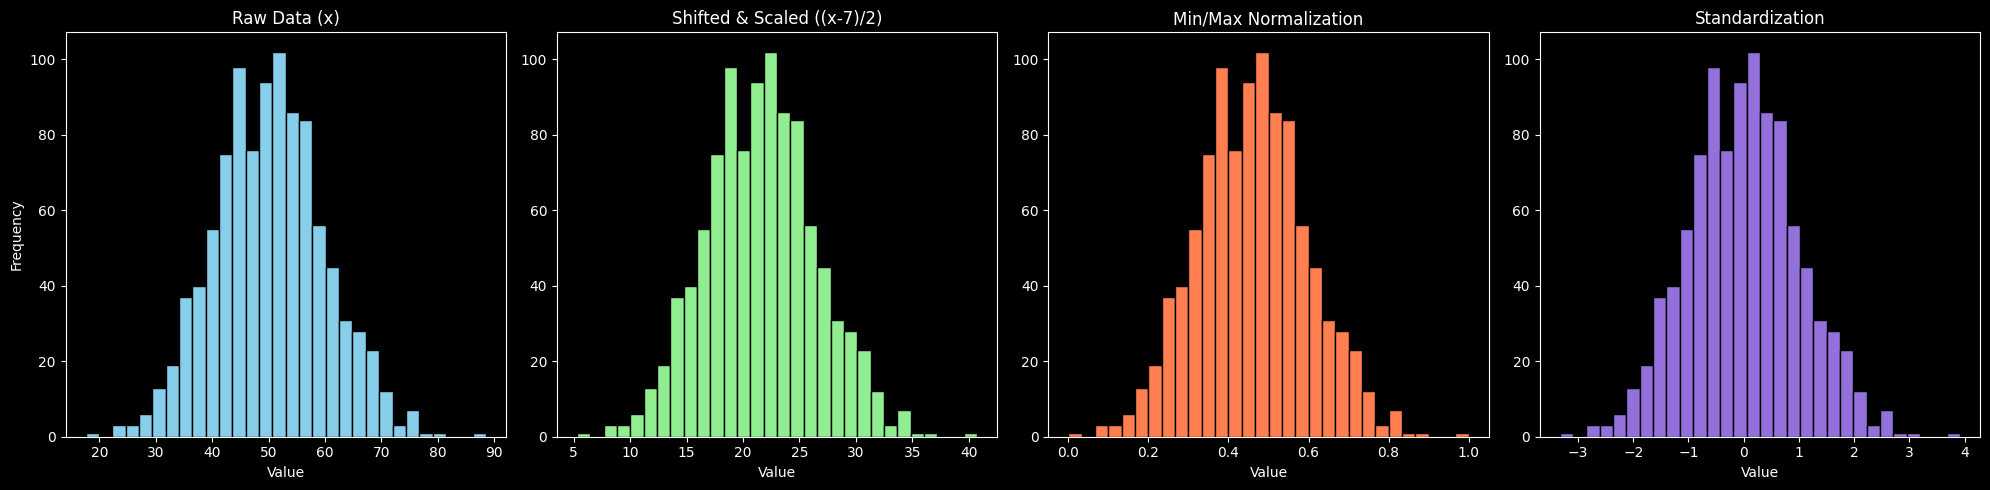

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
x = np.random.normal(loc=50, scale=10, size=1000)

x_custom = (x - 7) / 2

x_min = np.min(x)
x_max = np.max(x)
x_norm = (x - x_min) / (x_max - x_min)

x_mean = np.mean(x)
sigma = np.std(x)
x_std = (x - x_mean) / sigma

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].hist(x, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Raw Data (x)')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(x_custom, bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Shifted & Scaled ((x-7)/2)')
axes[1].set_xlabel('Value')

axes[2].hist(x_norm, bins=30, color='coral', edgecolor='black')
axes[2].set_title('Min/Max Normalization')
axes[2].set_xlabel('Value')

axes[3].hist(x_std, bins=30, color='mediumpurple', edgecolor='black')
axes[3].set_title('Standardization')
axes[3].set_xlabel('Value')

plt.tight_layout()
plt.show()

In [2]:
datasets = {
    "Raw Data (x)": x,
    "Shifted & Scaled ((x-7)/2)": x_custom,
    "Min/Max Normalization": x_norm,
    "Standardization": x_std
}

print(f"{'Dataset':<30} | {'Mean':>10} | {'Std Dev':>10} | {'Min':>10} | {'Max':>10}")
print("-" * 81)

for name, data in datasets.items():
    mean_val = np.mean(data)
    std_val = np.std(data)
    min_val = np.min(data)
    max_val = np.max(data)
    print(f"{name:<30} | {mean_val:>10.4f} | {std_val:>10.4f} | {min_val:>10.4f} | {max_val:>10.4f}")

Dataset                        |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------------
Raw Data (x)                   |    50.1933 |     9.7873 |    17.5873 |    88.5273
Shifted & Scaled ((x-7)/2)     |    21.5967 |     4.8936 |     5.2937 |    40.7637
Min/Max Normalization          |     0.4596 |     0.1380 |     0.0000 |     1.0000
Standardization                |    -0.0000 |     1.0000 |    -3.3315 |     3.9167


As you can see, min/max normalization correctly mapped our data to a range of 0 to 1. This is great when we specifically need our data bounded within a strict range.

However, this technique is highly sensitive to outliers. In extreme cases, a single massive outlier will stretch the scale so much that the rest of our normal data gets crammed into a tiny fraction of that 0–1 space, resulting in an incredibly small standard deviation. This can mess up how our models react later on, as the algorithms will struggle to distinguish between those microscopically small changes in the data.

That is why standardization, which is much better at preserving the original spacing and variance of the data, is the usual default when we need to scale our features.

Now let's jump into action, let us start with a helper `graph_3d` to graph the cost function landscape and how our gradient descent traverses it with and without standardization. Also we will have a look at how our landscape looks like.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from linreg.linreg import LinearRegression

def graph_3d(model, generator, X, y_actual, true_w1, true_w2, true_bias, grid_resolution=100, elev=30, azim=120):
    """
    Consumes a training generator to extract weight history, then generates
    a 3D loss surface plot and overlays the gradient descent path.
    """
    w1_history = []
    w2_history = []
    bias_history = []

    for weights in generator:
        w1_history.append(weights[0, 0])
        w2_history.append(weights[0, 1])
        bias_history.append(weights[0, 2])

    final_bias = bias_history[-1]

    # 2. Dynamically calculate boundaries with a 20% margin
    w1_min = min(min(w1_history), true_w1)
    w1_max = max(max(w1_history), true_w1)
    w1_margin = (w1_max - w1_min) * 0.2 if w1_max != w1_min else 1.0
    w1_bounds = (w1_min - w1_margin, w1_max + w1_margin)

    w2_min = min(min(w2_history), true_w2)
    w2_max = max(max(w2_history), true_w2)
    w2_margin = (w2_max - w2_min) * 0.2 if w2_max != w2_min else 1.0
    w2_bounds = (w2_min - w2_margin, w2_max + w2_margin)

    # 3. Create the grid for the loss surface
    w1_range = np.linspace(w1_bounds[0], w1_bounds[1], grid_resolution)
    w2_range = np.linspace(w2_bounds[0], w2_bounds[1], grid_resolution)
    W1, W2 = np.meshgrid(w1_range, w2_range)
    Z = np.zeros_like(W1)

    # Calculate MSE for every combination on the grid using the model's method
    for i in range(W1.shape[0]):
        for j in range(W1.shape[1]):
            model.weights = np.array([[W1[i, j], W2[i, j], final_bias]])
            Z[i, j] = model.calculate_mse(X, y_actual)

    # 4. Calculate the exact cost for each step in our history
    cost_history = []
    for w1, w2, bias in zip(w1_history, w2_history, bias_history):
        model.weights = np.array([[w1, w2, bias]])
        cost_history.append(model.calculate_mse(X, y_actual))

    # Calculate true minimum cost
    model.weights = np.array([[true_w1, true_w2, true_bias]])
    true_cost = model.calculate_mse(X, y_actual)

    # Restore model to its final trained state just in case
    model.weights = np.array([[w1_history[-1], w2_history[-1], bias_history[-1]]])

    # 5. Create the 3D plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(W1, W2, Z, cmap='viridis', alpha=0.6, edgecolor='none')

    ax.plot(w1_history, w2_history, cost_history, color='red', marker='o',
            markersize=3, label='GD Path', linewidth=2)

    ax.scatter(true_w1, true_w2, true_cost, color='black', s=200, marker='*', label='True Minimum')

    ax.set_title("3D Loss Surface and Gradient Descent Path")
    ax.set_xlabel("Weight 1 (Small Scale)")
    ax.set_ylabel("Weight 2 (Large Scale)")
    ax.set_zlabel("Cost (MSE)")
    ax.legend()

    ax.view_init(elev=elev, azim=azim) # Rotate the graph to make the view better
    plt.show()

Let's start by instantiating our un-scaled data with one feature being very small (from -1 to 1) and the second being large (from -1000 to 1000), we will cover 3 scenarios:
1. Training on unscaled data with the usual value for LR=0.1
2. Training on unscaled data with a very small value for LR=1e-6
3. Training on scaled data with the usual value of LR=0.1

In [4]:
from copy import deepcopy

n_samples = 100

np.random.seed(42)
X_small = np.random.rand(n_samples, 1)

X_large = np.random.rand(n_samples, 1) * 1000

X_unscaled = np.hstack((X_small, X_large))

true_w1, true_w2, true_bias = 105, 0.1, 10.0
y_actual = true_w1 * X_small + true_w2 * X_large + true_bias
y_actual += np.random.randn(n_samples, 1) * 5

init_model = LinearRegression(n_features=2, seed=42)
linreg_non_scaled = deepcopy(init_model)
linreg_non_scaled_small_lr = deepcopy(init_model)
linreg_scaled = deepcopy(init_model)

Now that we got all of our models instantiated we can begin showcasing what will happen in each scenario

## 1. Unscaled Data with LR=0.1

C:\Users\mrybczynski\Desktop\projects\python\ml-algorithms\linreg\linreg.py:101: RuntimeWarning: overflow encountered in matmul
  grad = (2 / n_samples) * y_diff @ X_w_ones
C:\Users\mrybczynski\Desktop\projects\python\ml-algorithms\linreg\linreg.py:104: RuntimeWarning: invalid value encountered in multiply
  self.l1_coeff * np.sign(self.weights) + 2 * self.l2_coeff * self.weights
C:\Users\mrybczynski\Desktop\projects\python\ml-algorithms\.venv\Lib\site-packages\numpy\_core\function_base.py:163: RuntimeWarning: invalid value encountered in multiply
  y *= step
C:\Users\mrybczynski\Desktop\projects\python\ml-algorithms\.venv\Lib\site-packages\numpy\_core\function_base.py:173: RuntimeWarning: invalid value encountered in add
  y += start
C:\Users\mrybczynski\Desktop\projects\python\ml-algorithms\linreg\linreg.py:74: RuntimeWarning: overflow encountered in square
  return np.float64(np.mean((y_actual - y_predict) ** 2))
C:\Users\mrybczynski\Desktop\projects\python\ml-algorithms\.venv\Lib\s

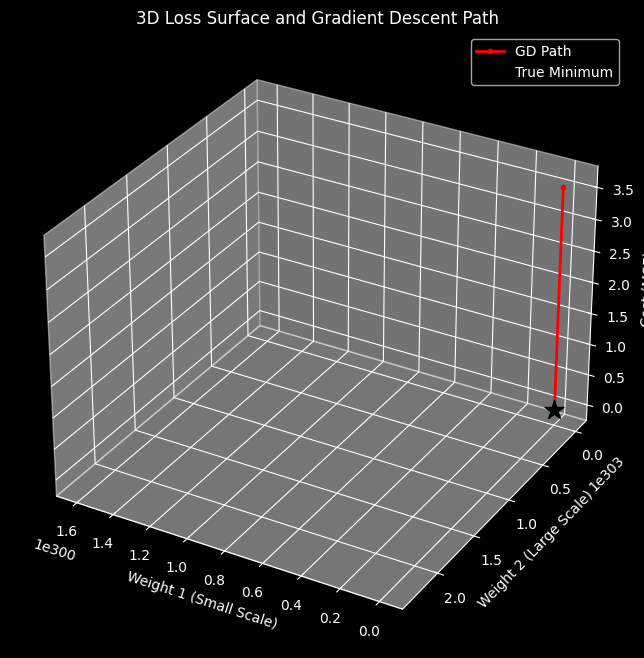

In [5]:
generator = linreg_non_scaled.fit_generator(
    X=X_unscaled,
    y=y_actual,
    learning_rate=0.1,
    batch_size=n_samples,
    epochs=150
)

graph_3d(
    model=linreg_non_scaled,
    generator=generator,
    X=X_unscaled,
    y_actual=y_actual,
    true_w1=true_w1,
    true_w2=true_w2,
    true_bias=true_bias,
)

## 2. Unscaled with LR=1e-6

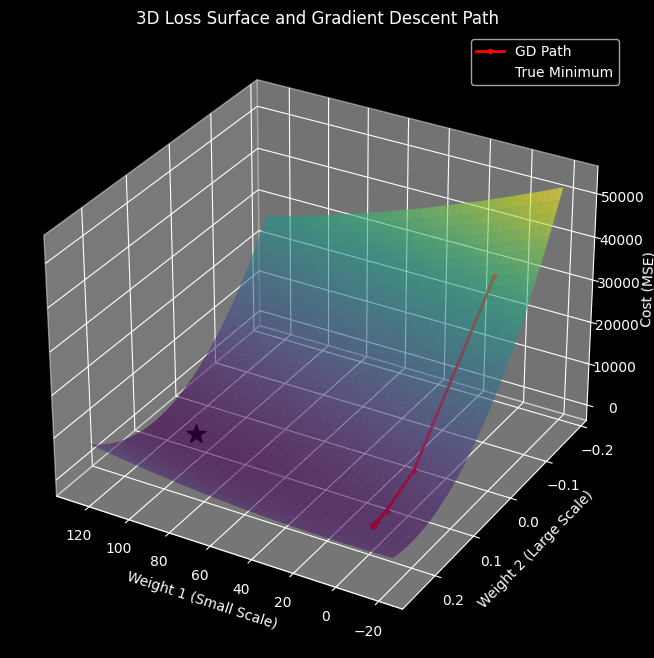

In [6]:
generator = linreg_non_scaled_small_lr.fit_generator(
    X=X_unscaled,
    y=y_actual,
    learning_rate=1e-6,
    batch_size=n_samples,
    epochs=250
)

graph_3d(
    model=linreg_non_scaled_small_lr,
    generator=generator,
    X=X_unscaled,
    y_actual=y_actual,
    true_w1=true_w1,
    true_w2=true_w2,
    true_bias=true_bias,
)

## Scaled data with LR=0.1

But first we need to obviously scale our data :). We will do this using a standardization technique mentioned before.

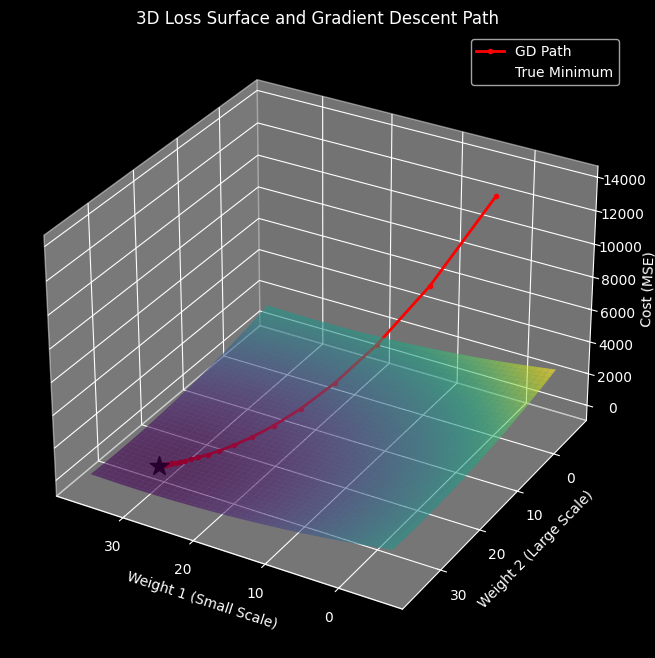

In [7]:
X_scaled = (X_unscaled - np.mean(X_unscaled, axis=0, keepdims=True)) / np.std(X_unscaled, axis=0, keepdims=True)

# we need to recalculate true w1 and w2 to because the underlying x has been changed
X_scaled_w_ones = np.c_[X_scaled, np.ones(n_samples)]
true_weights_scaled = np.linalg.inv(X_scaled_w_ones.T @ X_scaled_w_ones) @ X_scaled_w_ones.T @ y_actual
true_weights_flat = true_weights_scaled.flatten()

true_w1_scaled = true_weights_flat[0]
true_w2_scaled = true_weights_flat[1]
true_bias_scaled = true_weights_flat[2]

generator = linreg_scaled.fit_generator(
    X=X_scaled,
    y=y_actual,
    learning_rate=0.1,
    batch_size=n_samples,
    epochs=150
)

graph_3d(
    model=linreg_scaled,
    generator=generator,
    X=X_scaled,
    y_actual=y_actual,
    true_w1=true_w1_scaled,
    true_w2=true_w2_scaled,
    true_bias=true_bias_scaled
)

So, let's quickly summarize what happened.

In the first scenario our code failed miserably, the gradient calculated for the unscaled feature must have been massive and after applying not so small of the learning rate our calculations quickly got stopped by an overflow and a few of additional Runtimes that have happened after it.

In the second scenario, we were able to execute our code with a learning rate of 1e-6 witch is very small. After successfully minimizing the cost with respect to the large feature we have run out of epochs because the learning rate was too small we were not able to correctly minimize the cost with respect to the small feature.

In the last scenario we were actually able to arrive to the global minimum of the cost function. These graphs show how important feature scaling is when we work with data using Linear regression and similar models depending on the gradient descent.

### Mathematical inquiry
We can also come up with a little bit of math to solidify the understanding of the Gradient values, basically in Linear Regression problem the value of the gradient of cost is calculated as follows:
$$\frac{\partial MSE}{\partial w_k} = \frac{2}{N} \sum_{i=1}^{N} (\hat{y}^{(i)} - y^{(i)}) \cdot x_k^{(i)}$$

so given we have to features $x_k$ for k=1 and k=2, if the feature of k=1 will have a much larger scale (-1000, 1000) and the feature k=2 a much smaller scale (-1, 1), the values of the corresponding gradient dimensions will differ greatly. For k=1 the gradient value will be about 1000 of magnitude higher than the value for k=2, which will make GD focus much more on the large feature.

## Additional example, the "Zig-Zag"
In many educational videos they showcase that the optimization path might become very chaotic without standarization. We might pretty much overshoot the step in the direction of the large feature and end up on the opposite side of the cost function curve, which slows down the process. In step two we performed a "crawl" with very small learning rate but if we try to go for a bigger one, to learn faster along the other axis (as you can remember the small feature learning was too slow), while keeping in mind to keep it low enough not to get a gradient overflow - we will receive a "Zig-Zag" often showcased on educational videos on this topic.
Here is how the graph would look with no standardization and LR = 2.7e-6.

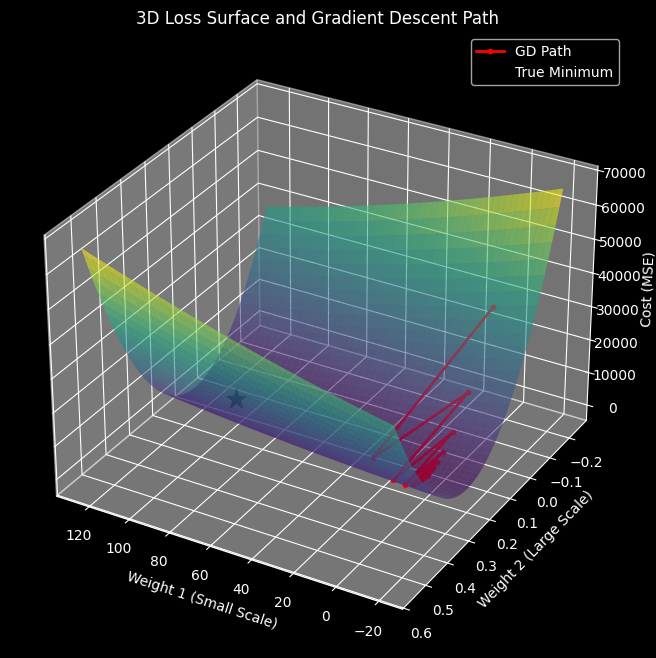

In [8]:
generator = init_model.fit_generator(
    X=X_unscaled,
    y=y_actual,
    learning_rate=2.7e-6,
    batch_size=n_samples,
    epochs=250
)

graph_3d(
    model=init_model,
    generator=generator,
    X=X_unscaled,
    y_actual=y_actual,
    true_w1=true_w1,
    true_w2=true_w2,
    true_bias=true_bias,
)